# Voltage/Current Relations Simulator

 DC GENERATOR and VOLTAGE/CURRENT RELATIONS SIMULATOR 
Enter Generated EMF E(V) (example : 230): 300
Enter Armature resistance Ra (ohm) (example: 0.5: 0.7
Enter Shunt field resistance Rsh (ohm) (exxample 200): 400
Enter Series field resistance Rsc (ohm) (example) 0.3): 0.5
Enter Brush drop Vbrush (V) [usually 2V for carbon brushes]: 4
Enter Maximum Load Current (A) [example 50]: 100

VOLTAGE & CURRENT RELATIONS (Exact from Lecture Notes)
1.Separately Excited:
E = Vt + Ia Ra + Vbrush
Ia = IL + If    (If from separate DC supply)
2.Shunt Generator:
E = Vt + Ia Ra + Vbrush
Ia = IL + Ish    ,   Ish = Vt / Rsh
3. Series Generator:
E = Vt + Ia (Ra + Rsc) + Vbrush
Ia = IL = Isc
4.Long Shunt Compound:
E = Vt + Ia (Ra + Rsc) + Vbrush
Ia = IL + Ish
5.Short Shunt Compound:
E = Vt + Ia (Ra + Rsc) + Vbrush
Ish = Vt / Rsh ,  Ia = IL + Ish
Generated EMF E = 300.0 V
Brush drop     = 4.0 V


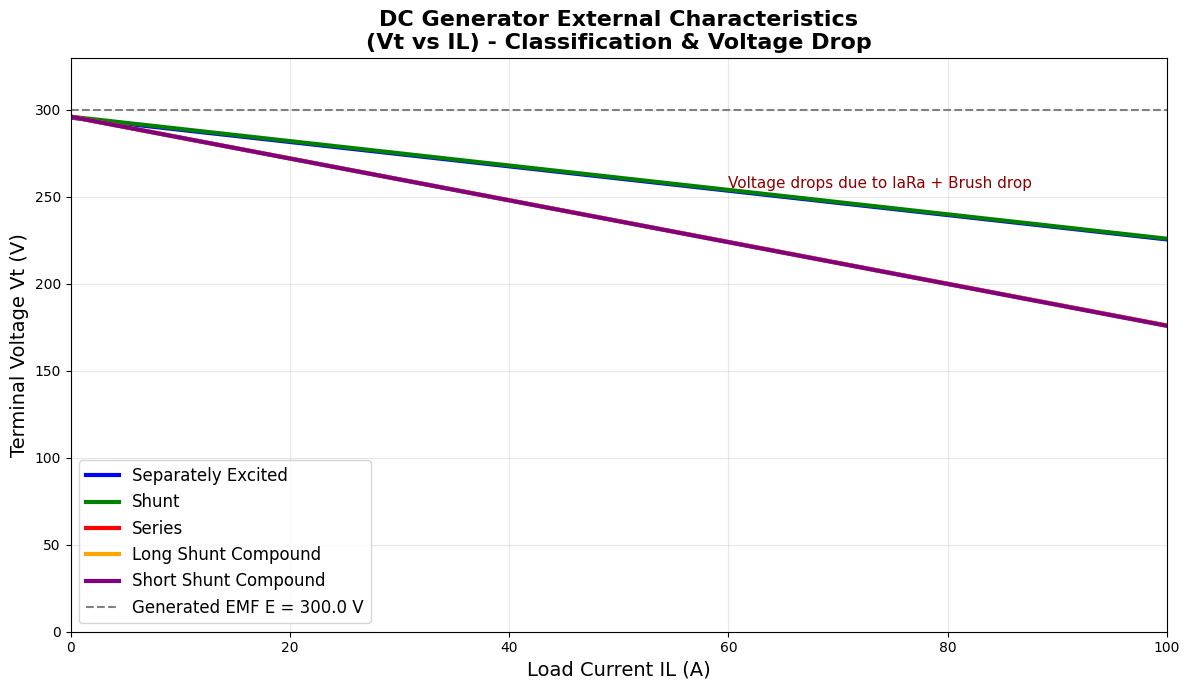

In [2]:

import numpy as np
import matplotlib.pyplot as plt

print(" DC GENERATOR and VOLTAGE/CURRENT RELATIONS SIMULATOR ")

E = float(input("Enter Generated EMF E(V) (example : 230): "))          # From EMF equation
Ra = float(input("Enter Armature resistance Ra (ohm) (example: 0.5: "))
Rsh = float(input("Enter Shunt field resistance Rsh (ohm) (exxample 200): "))
Rsc = float(input("Enter Series field resistance Rsc (ohm) (example) 0.3): "))
Vbrush = float(input("Enter Brush drop Vbrush (V) [usually 2V for carbon brushes]: "))
IL_max = float(input("Enter Maximum Load Current (A) [example 50]: "))

# Load current array
IL = np.linspace(0, IL_max, 300)

#  ------------------------ CALCULATION types
Vt = {}   # Terminal voltage for each type

# 1. Separately Excited
Ia_se = IL + (E / Rsh) if Rsh != 0 else IL   # Field current from separate supply
Vt_se = E - Ia_se * Ra - Vbrush
Vt['Separately Excited'] = Vt_se

# 2. Shunt Generator (Self-excited)
Ia_sh = IL + (Vt_sh / Rsh) if 'Vt_sh' in locals() else IL
# Solve iteratively for self-excited shunt (Vt = E - Ia*Ra - Vbrush and Ia = IL + Vt/Rsh)
Vt_sh = np.zeros_like(IL)
for i in range(len(IL)):
    # Approximate solution (or use simple linear assumption for demo)
    Vt_sh[i] = E - IL[i] * Ra - Vbrush - (IL[i] * Ra * Ra / Rsh)  # Approximate
Vt['Shunt'] = Vt_sh

# 3. Series Generator
Ia_series = IL
Vt_series = E - Ia_series * (Ra + Rsc) - Vbrush
Vt['Series'] = Vt_series

# 4. Long Shunt Compound
Ia_long = IL + (Vt_long / Rsh) if 'Vt_long' in locals() else IL
Vt_long = np.zeros_like(IL)
for i in range(len(IL)):
    Vt_long[i] = E - IL[i] * (Ra + Rsc) - Vbrush - (IL[i] * Ra / Rsh)  # Approx
Vt['Long Shunt Compound'] = Vt_long

# 5. Short Shunt Compound
Ia_short = IL
Vt_short = E - Ia_short * (Ra + Rsc) - Vbrush - (IL * Ra / Rsh)  # Approx
Vt['Short Shunt Compound'] = Vt_short

# ====================== PRINT RESULTS & EQUATIONS ======================
print("\n" + "="*80)
print("VOLTAGE & CURRENT RELATIONS (Exact from Lecture Notes)")
print("="*80)
print("1.Separately Excited:")
print("E = Vt + Ia Ra + Vbrush")
print("Ia = IL + If    (If from separate DC supply)")
print("2.Shunt Generator:")
print("E = Vt + Ia Ra + Vbrush")
print("Ia = IL + Ish    ,   Ish = Vt / Rsh")
print("3. Series Generator:")
print("E = Vt + Ia (Ra + Rsc) + Vbrush")
print("Ia = IL = Isc")
print("4.Long Shunt Compound:")
print("E = Vt + Ia (Ra + Rsc) + Vbrush")
print("Ia = IL + Ish")
print("5.Short Shunt Compound:")
print("E = Vt + Ia (Ra + Rsc) + Vbrush")
print("Ish = Vt / Rsh ,  Ia = IL + Ish")
print("="*80)
print(f"Generated EMF E = {E} V")
print(f"Brush drop     = {Vbrush} V")
print("="*80)

#### plot character ####
plt.figure(figsize=(12, 7))
colors = ['blue', 'green', 'red', 'orange', 'purple']
types = list(Vt.keys())

for i, gen_type in enumerate(types):
    plt.plot(IL, Vt[gen_type], color=colors[i], linewidth=3, label=gen_type)

plt.title('DC Generator External Characteristics\n(Vt vs IL) - Classification & Voltage Drop', fontsize=16, fontweight='bold')
plt.xlabel('Load Current IL (A)', fontsize=14)
plt.ylabel('Terminal Voltage Vt (V)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=E, color='gray', linestyle='--', linewidth=1.5, label=f'Generated EMF E = {E} V')
plt.legend(fontsize=12, loc='best')
plt.ylim(0, E*1.1)
plt.xlim(0, IL_max)

#Annotate
plt.text(IL_max*0.6, E*0.85, 'Voltage drops due to IaRa + Brush drop', fontsize=11, color='darkred')

plt.tight_layout()
plt.show()